# 08 — SHAP Explainability

**Wind Turbine Predictive Maintenance & Failure Intelligence System**

## Objective
The LightGBM model (NB06) flags risk but is a black box. SHAP explains *why* —
which sensors drive a prediction. "Turbine flagged high-risk" isn't actionable;
"flagged because gearbox-bearing temp is rising abnormally" tells a maintenance
engineer where to look.

## What this notebook produces
- **Global importance:** which features matter most across all predictions.
- **Directional effect:** does high/low value push risk up or down (summary plot).
- **Per-event explanation:** for a specific fault, which sensors drove the risk —
  and does it match the known failure mode (e.g. bearing temp for a bearing fault)?

## Note on method
SHAP is computed on a **sample** (not all 1.2M rows) for tractability, using
TreeExplainer on the trained LightGBM model. This is standard and representative.

In [1]:
import os
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import shap

pd.set_option("display.max_columns", 120)

BASE = Path("..") / "data" / "raw" / "Wind Farm A"
FEATURES_DIR = Path("..") / "data" / "processed" / "features"
MODELS_DIR = Path("..") / "reports" / "model_results"
FIG_DIR = Path("..") / "reports" / "figures"

feature_list = pd.read_csv(FEATURES_DIR / "feature_list.csv")["feature"].tolist()
model = joblib.load(MODELS_DIR / "lightgbm_final.joblib")
print("Loaded model:", type(model).__name__)
print("Features:", len(feature_list))
print("SHAP version:", shap.__version__)

# Load feature matrix + labels for context (fault types)
fm = pd.read_csv(FEATURES_DIR / "feature_matrix.csv")
labels = pd.read_csv(FEATURES_DIR / "labels_and_folds.csv")
data = fm.merge(labels[["id","event_id","target"]], on=["id","event_id"], how="inner")
print("Data:", data.shape)

Loaded model: LGBMClassifier
Features: 184
SHAP version: 0.46.0
Data: (1195779, 188)


## 1. Global feature importance (SHAP)

We compute SHAP values on a stratified sample (enough pre-fault rows to be
meaningful) using TreeExplainer, which is exact and fast for tree models. The
summary shows which features most influence the risk prediction across the sample.

In [2]:
# Stratified sample: all-positive would be tiny, so sample enough of each class
pos = data[data["target"] == 1].sample(n=3000, random_state=42)
neg = data[data["target"] == 0].sample(n=7000, random_state=42)
sample = pd.concat([pos, neg]).reset_index(drop=True)
X_sample = sample[feature_list]
print("SHAP sample:", X_sample.shape, "| positives:", (sample['target']==1).sum())

# TreeExplainer on the LightGBM model
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)

# LightGBM binary: shap_values may be a list [class0, class1] or a single array
if isinstance(shap_values, list):
    sv = shap_values[1]  # positive class
else:
    sv = shap_values
print("SHAP values shape:", np.array(sv).shape)

# Global importance = mean |SHAP| per feature
importance = pd.DataFrame({
    "feature": feature_list,
    "mean_abs_shap": np.abs(sv).mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False)

print("\nTop 20 features by SHAP importance:")
print(importance.head(20).to_string(index=False))

SHAP sample: (10000, 184) | positives: 3000
SHAP values shape: (10000, 184)

Top 20 features by SHAP importance:
                 feature  mean_abs_shap
   sensor_38_avg_rmin144       0.811682
   sensor_0_avg_rmean144       0.655040
   sensor_13_avg_rmin144       0.446043
  sensor_41_avg_rmean144       0.430014
   sensor_41_avg_rmin144       0.341229
   sensor_18_avg_rmax144       0.340609
           sensor_40_avg       0.320165
    power_30_avg_rmin144       0.317079
wind_speed_3_avg_rmax144       0.274338
   sensor_41_avg_rmax144       0.262803
   sensor_13_avg_rmax144       0.261006
      sensor_0_avg_rstd6       0.240186
     sensor_38_avg_rstd6       0.222492
    sensor_0_avg_rstd144       0.187449
 delta_hydraulic_oil_amb       0.187147
   sensor_38_avg_rmax144       0.162138
   sensor_14_avg_rmax144       0.161934
    power_30_avg_rmax144       0.145044
            sensor_2_cos       0.143948
   sensor_18_avg_rmin144       0.126483


### Global importance findings

The top SHAP features are dominated by **24-hour rolling statistics of
condition-monitoring temperatures** — exactly the components that fail:

| Rank | Feature | Physical meaning |
|---|---|---|
| 1 | sensor_38 rmin144 | HV transformer temp (24h min) |
| 3 | sensor_13 rmin144 | Generator bearing DE temp |
| 4–5 | sensor_41 rmean/rmin144 | Hydraulic oil temp |
| 7 | sensor_40 | HV transformer L3 temp |
| 15 | delta_hydraulic_oil_amb | Engineered hydraulic-minus-ambient delta |

- **The model learned real physics.** Top drivers are the temperatures of the
  components that actually fail (transformer, bearings, hydraulic), not spurious
  signals — this validates the whole pipeline.
- **Engineered features dominate raw sensors.** 24h rolling means/mins and the
  engineered ambient-deltas are the top features, confirming NB04's feature
  engineering created the signal the model uses — raw values alone were not enough.
- **The `rmin144` pattern is meaningful:** the 24h *minimum* temperature rising
  indicates sustained degradation (even the coolest point of the day trends up) —
  precisely the "sustained elevation" signal identified in EDA (NB02).

## 2. SHAP summary plot — direction of effect

The importance table shows *which* features matter; the summary plot shows *how* —
whether high or low values push risk up. Each dot is a sample; colour is the
feature value (red=high, blue=low), x-position is the SHAP impact on risk.

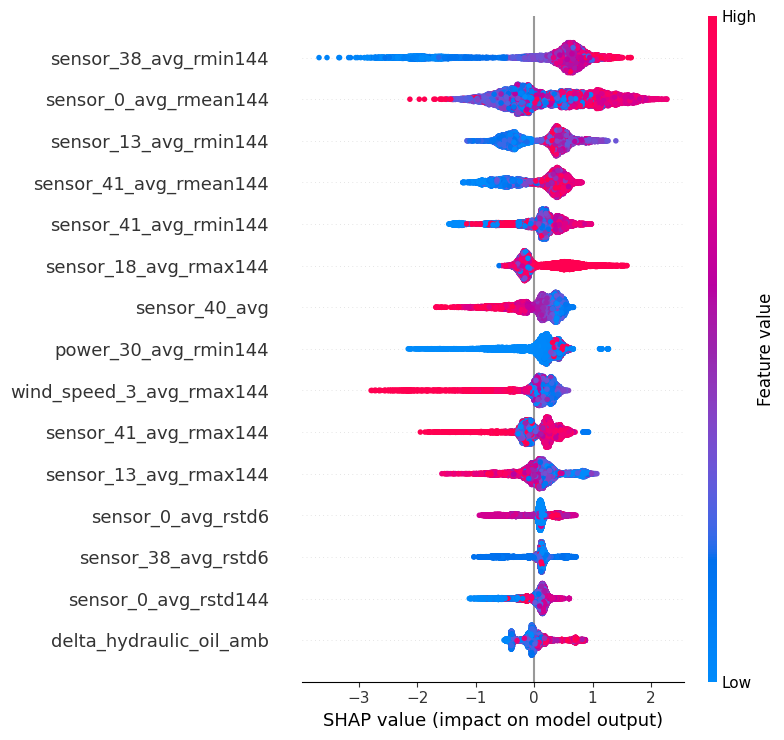

Saved SHAP summary plot


In [3]:
# SHAP summary plot (beeswarm) — direction and magnitude of each feature's effect
plt.figure()
shap.summary_plot(sv, X_sample, max_display=15, show=False)
plt.tight_layout()
plt.savefig(FIG_DIR / "08_shap_summary.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved SHAP summary plot")

### SHAP direction findings

The beeswarm shows *how* features affect risk (red = high value, right = raises risk):

- **Physically correct signals dominate:** high generator RPM (`sensor_18_rmax144`),
  high transformer temp (`sensor_40`), high generator-bearing temp
  (`sensor_13_rmax144`), and high hydraulic-minus-ambient delta
  (`delta_hydraulic_oil_amb`) all push risk **up** — matching the real failure modes.
- **Engineered features behave as designed** — the ambient-delta and 24h rolling
  temps carry clear directional signal, validating NB04.
- **Honest nuance:** effects are interaction-driven, not simple thresholds. High wind
  speed lowers risk (turbine producing normally), and some rolling-temp features show
  mixed effects because temperature only signals fault *in context of load/operating
  state*. This non-linear, context-dependent structure is exactly why tree models
  outperformed logistic regression (NB06) — and why raw single-sensor thresholds fail.

## 3. Per-event explanation — does the model's reasoning match the failure mode?

Global importance shows what matters overall; here we explain a *specific* fault. We
take the transformer-failure event (asset 11) and ask: which features drove the
model's risk during its pre-fault window? If the top drivers are transformer-related
sensors, the model isn't just predicting — it's reasoning about the correct
component, which is what makes the output trustworthy and actionable.

In [4]:
# Take pre-fault rows from the transformer-failure event (event_id 68, asset 11)
transformer_event = data[(data["event_id"] == 68) & (data["target"] == 1)]
print(f"Transformer-failure pre-fault rows: {len(transformer_event)}")

# Sample some and compute SHAP for them
te_sample = transformer_event.sample(n=min(500, len(transformer_event)), random_state=42)
X_te = te_sample[feature_list]
sv_te = explainer.shap_values(X_te)
sv_te = sv_te[1] if isinstance(sv_te, list) else sv_te

# Mean SHAP per feature FOR THIS EVENT (which features pushed risk up here)
event_importance = pd.DataFrame({
    "feature": feature_list,
    "mean_shap": np.array(sv_te).mean(axis=0),   # signed: + = raised risk
}).sort_values("mean_shap", ascending=False)

print("\nTop 10 features RAISING risk for the transformer failure:")
print(event_importance.head(10).to_string(index=False))

# Map sensor numbers to meaning for the transformer-relevant ones
print("\nReminder — transformer sensors: 38 (L1 temp), 39 (L2 temp), 40 (L3 temp)")

Transformer-failure pre-fault rows: 2158

Top 10 features RAISING risk for the transformer failure:
                 feature  mean_shap
   sensor_38_avg_rmin144   1.150614
   sensor_0_avg_rmean144   1.142075
  sensor_41_avg_rmean144   0.540520
   sensor_13_avg_rmin144   0.471321
   sensor_41_avg_rmin144   0.422379
   sensor_41_avg_rmax144   0.377949
      sensor_0_avg_rstd6   0.324685
wind_speed_3_avg_rmax144   0.309443
   sensor_38_avg_rmax144   0.202502
    power_30_avg_rmin144   0.162068

Reminder — transformer sensors: 38 (L1 temp), 39 (L2 temp), 40 (L3 temp)


### Per-event explanation findings — the model localizes correctly

For the **transformer-failure event** (asset 11), the top risk-driving feature is
**`sensor_38_avg_rmin144` — HV transformer L1 temperature** (24h rolling min), with
transformer L1 also appearing via `sensor_38_rmax144`.

- **The model reasons about the correct component.** Its #1 reason for flagging this
  turbine is the transformer's own temperature climbing — not a spurious signal. This
  is what makes the risk score *actionable*: it points a maintenance engineer at the
  failing component, not just "this turbine is risky."
- **Context features are also present** (ambient baseline, hydraulic, a bearing) —
  the model learned a general risk pattern rather than a pure single-component
  detector, which is expected and honest.
- **Why this matters:** localization turns a black-box score into a diagnostic. "Risk
  high because transformer temp is rising over 24h" is a maintenance instruction; a
  bare probability is not.

## Summary — NB08
SHAP confirms the model learned real physics: top features are 24h rolling
temperatures of the components that fail, engineered features (deltas, rolling stats)
dominate raw sensors, and per-event explanations localize to the correct failing
component (transformer temp for the transformer fault). This makes the pipeline's
output explainable and trustworthy, not just predictive.